# 04 — Modelling & Selection

**Insurance Claim Fraud Detection & Action Recommendation System**

This is the core modelling notebook. It builds two candidate model families
(XGBoost, LightGBM), searches over model + balancing strategy +
hyperparameters with Optuna, and selects a final configuration using
**validation and cross-validation only** — the test set is never opened here.

**What this notebook does:**
1. Loads Notebook 02/03's outputs — train/val splits, fitted preprocessing
   pipeline, and the `experiments.csv` evidence trail — recreates nothing
2. Reuses Notebook 03's evaluation harness unchanged (same metrics, same CV,
   same logging) so candidates are measured identically to baselines
3. Structurally proves the #1 leakage trap is closed: SMOTENC runs inside CV
   folds only, via an `imblearn.Pipeline`, verified with a direct test
4. Defines the `Experiment` class — one config (model + balancing +
   hyperparameters) evaluated the same way every time, the engine Optuna calls
5. Runs a 100-trial Optuna search (TPE sampler, median pruner) over four
   candidate arms: {XGBoost, LightGBM} x {class_weight, SMOTENC}
6. Selects the best configuration on CV PR-AUC, checks it against validation
   for overfitting, and compares it to the Notebook 03 baselines
7. Saves the selected model and its configuration to Drive

**Explicitly out of scope here:** touching the test set, calibration,
threshold selection, risk tiers, and resampling anywhere outside a CV fold.
Those belong to Notebooks 05-06 (and the resampling boundary is enforced
structurally, not just by convention - see Section 5).

## 1. Environment & Google Drive Setup

Same conventions as Notebooks 01-03: everything derives from one
`PROJECT_ROOT`, Drive is mounted first, and every expected input is verified
to exist before this notebook does any work.

In [2]:
"""Notebook 04 - Modelling & Selection: imports and shared configuration."""
import json
from dataclasses import dataclass, field
from datetime import datetime, timezone
from pathlib import Path
from typing import Optional

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
!pip install optuna
import optuna
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, brier_score_loss, f1_score, matthews_corrcoef,
    precision_recall_curve, precision_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.utils.validation import check_is_fitted
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

TARGET_COL = "FraudFound_P"
RANDOM_STATE = 42
optuna.logging.set_verbosity(optuna.logging.INFO)  # per-trial output on purpose - no black box

# Same fixed categorical palette as Notebooks 01/03, kept self-contained here.
PALETTE = {
    "blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a", "yellow": "#eda100",
    "magenta": "#e87ba4", "green": "#008300", "violet": "#4a3aa7", "red": "#e34948",
}

saved_files = []  # every artifact written to Drive is recorded here for the final recap
print("Libraries imported.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 12.2 MB/s eta 0:00:00
Libraries imported.


### Mount Google Drive

In [3]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
except ModuleNotFoundError as exc:
    raise RuntimeError(
        "This notebook is designed to run in Google Colab with the team's shared "
        "Drive mounted. `google.colab` is not available in this environment - open "
        "the notebook in Colab and re-run."
    ) from exc

Mounted at /content/drive


### Define project paths

In [4]:
PROJECT_ROOT = Path("/content/drive/MyDrive/InsuranceFraudProject")

DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_MODELLING_DIR = RESULTS_DIR / "figures" / "modelling"
MODELS_DIR = PROJECT_ROOT / "models"

TRAIN_PATH = DATA_PROCESSED_DIR / "train.parquet"
VAL_PATH = DATA_PROCESSED_DIR / "val.parquet"
PIPELINE_PATH = MODELS_DIR / "preprocessing_pipeline.joblib"
EXPERIMENTS_CSV_PATH = RESULTS_DIR / "experiments.csv"

FIGURES_MODELLING_DIR.mkdir(parents=True, exist_ok=True)

print("Project configuration")
print("-" * 60)
print(f"PROJECT_ROOT              : {PROJECT_ROOT}")
print(f"TRAIN_PATH                 : {TRAIN_PATH}")
print(f"VAL_PATH                   : {VAL_PATH}")
print(f"PIPELINE_PATH              : {PIPELINE_PATH}")
print(f"EXPERIMENTS_CSV_PATH        : {EXPERIMENTS_CSV_PATH}")
print(f"FIGURES_MODELLING_DIR       : {FIGURES_MODELLING_DIR}")
print("\nNote: test.parquet is intentionally never referenced in this notebook.")

Project configuration
------------------------------------------------------------
PROJECT_ROOT              : /content/drive/MyDrive/InsuranceFraudProject
TRAIN_PATH                 : /content/drive/MyDrive/InsuranceFraudProject/data/processed/train.parquet
VAL_PATH                   : /content/drive/MyDrive/InsuranceFraudProject/data/processed/val.parquet
PIPELINE_PATH              : /content/drive/MyDrive/InsuranceFraudProject/models/preprocessing_pipeline.joblib
EXPERIMENTS_CSV_PATH        : /content/drive/MyDrive/InsuranceFraudProject/results/experiments.csv
FIGURES_MODELLING_DIR       : /content/drive/MyDrive/InsuranceFraudProject/results/figures/modelling

Note: test.parquet is intentionally never referenced in this notebook.


### Verify expected inputs exist

Four inputs are required: the training split, the validation split, the
fitted preprocessing pipeline (all from Notebook 02), and `experiments.csv`
(Notebook 03's evidence trail — read here, never recreated, to pull the
baseline reference numbers used in the final comparison).

In [5]:
missing_inputs = []
for label, path in [
    ("train.parquet", TRAIN_PATH), ("val.parquet", VAL_PATH),
    ("preprocessing_pipeline.joblib", PIPELINE_PATH), ("experiments.csv", EXPERIMENTS_CSV_PATH),
]:
    if not path.exists():
        missing_inputs.append((label, path))

if missing_inputs:
    details = "\n".join(f"  - {label}: {path}" for label, path in missing_inputs)
    raise FileNotFoundError(
        f"Missing required input(s):\n{details}\n\n"
        "Run 02_preprocessing_and_splitting.ipynb and 03_baseline.ipynb first - this "
        "notebook loads their saved splits, fitted pipeline, and experiment log "
        "rather than recreating them."
    )

print("Found train.parquet, val.parquet, the fitted preprocessing pipeline, and experiments.csv.")

Found train.parquet, val.parquet, the fitted preprocessing pipeline, and experiments.csv.


## 2. Load Notebook 02/03's Outputs

Loaded, not recreated. **`test.parquet` is never loaded here** — model
selection happens on validation/CV only; the locked test set is opened once,
later, in Notebook 06.

In [6]:
train_df = pd.read_parquet(TRAIN_PATH)
val_df = pd.read_parquet(VAL_PATH)
preprocessing_pipeline = joblib.load(PIPELINE_PATH)

print(f"train_df: {train_df.shape[0]:,} rows x {train_df.shape[1]} columns")
print(f"val_df:   {val_df.shape[0]:,} rows x {val_df.shape[1]} columns")
print(f"train fraud rate: {train_df[TARGET_COL].mean() * 100:.2f}%")
print(f"val fraud rate:   {val_df[TARGET_COL].mean() * 100:.2f}%")

train_df: 10,793 rows x 30 columns
val_df:   2,313 rows x 30 columns
train fraud rate: 5.99%
val fraud rate:   6.01%


## 3. Apply the Fitted Preprocessing Pipeline

`.transform()` only, exactly as in Notebook 03 - `.fit()` is never called on
this pipeline here. The encoded feature names (`get_feature_names_out()`,
enabled by Notebook 02's `verbose_feature_names_out=True`) let us
automatically identify which encoded columns are categorical (one-hot /
ordinal) versus continuous (passthrough) — needed below for SMOTENC.

In [7]:
X_train_df = train_df.drop(columns=[TARGET_COL])
X_val_df = val_df.drop(columns=[TARGET_COL])

X_train = preprocessing_pipeline.transform(X_train_df)
X_val = preprocessing_pipeline.transform(X_val_df)
y_train = train_df[TARGET_COL].to_numpy()
y_val = val_df[TARGET_COL].to_numpy()

feature_names_out = preprocessing_pipeline.get_feature_names_out()
# One-hot ("nominal__...") and ordinal-encoded ("ordinal__...") columns are discrete/
# categorical for SMOTENC's purposes, regardless of which encoder produced them;
# imputed Age and the passthrough numeric columns are genuinely continuous.
categorical_feature_mask = np.array(
    [name.split("__")[0] in ("ordinal", "nominal") for name in feature_names_out]
)
categorical_feature_indices = np.where(categorical_feature_mask)[0].tolist()  # plain list: SMOTENC
# internally does `if self.categorical_features == "auto":`, which raises "ambiguous
# truth value" if given a numpy array instead of a list (elementwise string comparison).

n_negative = int((y_train == 0).sum())
n_positive = int((y_train == 1).sum())
class_weight_ratio = n_negative / n_positive  # scale_pos_weight for the class_weight arm

print(f"X_train: {X_train.shape}  |  X_val: {X_val.shape}")
print(f"{len(categorical_feature_indices)} of {len(feature_names_out)} encoded columns "
      f"treated as categorical for SMOTENC; {len(feature_names_out) - len(categorical_feature_indices)} continuous.")
print(f"class_weight_ratio (scale_pos_weight) = {n_negative}/{n_positive} = {class_weight_ratio:.2f}")

X_train: (10793, 93)  |  X_val: (2313, 93)
86 of 93 encoded columns treated as categorical for SMOTENC; 7 continuous.
class_weight_ratio (scale_pos_weight) = 10147/646 = 15.71


## 4. Evaluation Harness (Reused from Notebook 03)

Identical to Notebook 03 Section 5 — same function bodies, copied here
unchanged so baselines and candidates are measured by the exact same logic.
One additive, backward-compatible extension: `cross_validate_model` gains an
optional `trial` parameter used only by the Optuna objective in Section 8 —
called without it (every call in this section, and every baseline call in
Notebook 03), behaviour is byte-identical to Notebook 03. `compute_fraud_metrics`
includes Brier score, matching Notebook 03's calibration-aware version.

In [8]:
def compute_fraud_metrics(y_true: np.ndarray, y_pred: np.ndarray, y_proba: np.ndarray) -> dict:
    """Metrics for the fraud (positive) class, at whatever threshold produced y_pred.

    PR-AUC, ROC-AUC, and Brier score use y_proba (threshold-independent); the rest
    use y_pred (the model's default 0.5 cutoff here - no threshold tuning happens in
    this notebook, see Notebook 05).
    """
    return {
        "pr_auc": average_precision_score(y_true, y_proba),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "brier_score": brier_score_loss(y_true, y_proba),
    }


def cross_validate_model(model, X: np.ndarray, y: np.ndarray, n_splits: int = 5,
                          random_state: int = RANDOM_STATE, trial: Optional["optuna.Trial"] = None) -> pd.DataFrame:
    """Stratified k-fold CV: clone + refit `model` per fold, score on that fold's
    holdout. Returns one row of metrics per fold; callers take mean/std.
    Cloning per fold guarantees no fitted state leaks across folds.

    If `trial` is given, the running mean PR-AUC is reported to Optuna after each
    fold and optuna.TrialPruned is raised if the trial should be pruned - the only
    behavioural difference from Notebook 03's version.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_rows = []
    running_pr_auc = []
    for fold_idx, (fold_train_idx, fold_holdout_idx) in enumerate(skf.split(X, y)):
        fold_model = clone(model)
        fold_model.fit(X[fold_train_idx], y[fold_train_idx])
        y_pred = fold_model.predict(X[fold_holdout_idx])
        y_proba = fold_model.predict_proba(X[fold_holdout_idx])[:, 1]
        row = compute_fraud_metrics(y[fold_holdout_idx], y_pred, y_proba)
        row["fold"] = fold_idx
        row["fold_fraud_rate"] = y[fold_holdout_idx].mean()
        fold_rows.append(row)

        if trial is not None:
            running_pr_auc.append(row["pr_auc"])
            trial.report(float(np.mean(running_pr_auc)), step=fold_idx)
            if trial.should_prune():
                raise optuna.TrialPruned()
    return pd.DataFrame(fold_rows)


def summarize_cv(cv_results: pd.DataFrame) -> dict:
    """Collapse per-fold CV metrics into mean/std, keyed like 'pr_auc_mean'/'pr_auc_std'."""
    metric_cols = [c for c in cv_results.columns if c not in ("fold", "fold_fraud_rate")]
    summary = {}
    for col in metric_cols:
        summary[f"{col}_mean"] = cv_results[col].mean()
        summary[f"{col}_std"] = cv_results[col].std()
    return summary


def fit_and_evaluate(model, X_train_: np.ndarray, y_train_: np.ndarray,
                      X_eval: np.ndarray, y_eval: np.ndarray) -> dict:
    """Fit a fresh clone of `model` on the full training data, evaluate on X_eval/y_eval.
    Returns the fitted model and predictions alongside metrics, for reuse in plotting.
    """
    fitted = clone(model)
    fitted.fit(X_train_, y_train_)
    y_pred = fitted.predict(X_eval)
    y_proba = fitted.predict_proba(X_eval)[:, 1]
    return {
        "model": fitted, "y_pred": y_pred, "y_proba": y_proba,
        "metrics": compute_fraud_metrics(y_eval, y_pred, y_proba),
    }


def log_experiment(row: dict, path: Path) -> None:
    """Append one experiment row to the shared experiments.csv, creating it with a
    header if it doesn't exist yet. This is a full audit trail - re-running this
    notebook appends new rows rather than overwriting prior ones."""
    new_row_df = pd.DataFrame([row])
    combined = pd.concat([pd.read_csv(path), new_row_df], ignore_index=True) if path.exists() else new_row_df
    combined.to_csv(path, index=False)


print("Evaluation harness ready (reused from Notebook 03): compute_fraud_metrics, "
      "cross_validate_model, summarize_cv, fit_and_evaluate, log_experiment.")

Evaluation harness ready (reused from Notebook 03): compute_fraud_metrics, cross_validate_model, summarize_cv, fit_and_evaluate, log_experiment.


## 5. The #1 Leakage Trap, and How This Notebook Closes It

SMOTENC must only ever see a CV fold's *training* portion. If it were applied
before the train/val split, or once to the whole training set before CV, its
synthetic minority-class points would be built from neighbors that later end
up in a held-out fold (or worse, in validation) — the model would then be
scored partly on synthetic near-duplicates of its own training data.

**How it's structurally prevented, not just avoided by convention:** SMOTENC
is placed as a step inside an `imblearn.Pipeline`, together with the
classifier. `imblearn.Pipeline` (unlike a plain `sklearn.Pipeline`, which
can't hold a resampling step at all) resamples during `.fit()` / `.fit_resample()`
only — resampling is **skipped** during `.predict()` / `.predict_proba()`. Combined
with `cross_validate_model` (Section 4, unchanged from Notebook 03) — which
clones a fresh model per fold, fits on that fold's training indices, and
predicts on that fold's holdout indices — this guarantees SMOTENC only ever
resamples training data and is never invoked on a holdout fold. That's not
asserted by comment below; it's tested directly, on a slice of the real
encoded training data.

In [9]:
def test_no_fold_leakage_via_smotenc_pipeline() -> None:
    """Structural proof that an imblearn.Pipeline's SMOTENC step only ever resamples
    the data passed to .fit(), and is skipped at .predict() time. Uses a slice of the
    real encoded training data so the categorical-feature mask is genuinely valid,
    not a synthetic stand-in."""
    X_toy, y_toy = X_train[:400], y_train[:400]
    toy_train_idx, toy_holdout_idx = train_test_split(
        np.arange(len(X_toy)), test_size=0.25, stratify=y_toy, random_state=RANDOM_STATE,
    )
    toy_pipeline = ImbPipeline([
        ("resampler", SMOTENC(categorical_features=categorical_feature_indices,
                               random_state=RANDOM_STATE, k_neighbors=3)),
        ("classifier", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
    ])
    toy_pipeline.fit(X_toy[toy_train_idx], y_toy[toy_train_idx])

    y_pred_holdout = toy_pipeline.predict(X_toy[toy_holdout_idx])
    assert len(y_pred_holdout) == len(toy_holdout_idx), (
        "Prediction count changed at holdout time - SMOTENC must never resample "
        "anything except the .fit() call's own training data."
    )

    n_minority_before = int((y_toy[toy_train_idx] == 1).sum())
    n_majority_before = int((y_toy[toy_train_idx] == 0).sum())
    _, y_resampled = toy_pipeline.named_steps["resampler"].fit_resample(
        X_toy[toy_train_idx], y_toy[toy_train_idx]
    )
    n_minority_after = int((y_resampled == 1).sum())
    n_majority_after = int((y_resampled == 0).sum())
    assert n_minority_after > n_minority_before, (
        "SMOTENC did not oversample the minority class - the resampling mechanism "
        "looks like a silent no-op rather than actually balancing anything."
    )
    assert n_minority_after == n_majority_after, (
        "SMOTENC did not fully balance the classes under the default sampling_strategy."
    )
    print(f"PASSED: SMOTENC oversampled the minority class {n_minority_before} -> "
          f"{n_minority_after} during .fit() (majority stayed {n_majority_before}), and "
          f".predict() on the holdout returned exactly {len(y_pred_holdout)} rows "
          "(unchanged) - resampling never touches held-out data.")


test_no_fold_leakage_via_smotenc_pipeline()

PASSED: SMOTENC oversampled the minority class 20 -> 280 during .fit() (majority stayed 280), and .predict() on the holdout returned exactly 100 rows (unchanged) - resampling never touches held-out data.


## 6. Early Stopping Inside Cross-Validation

Both XGBoost and LightGBM support early stopping: hold out an internal
validation slice, stop adding trees once that slice's score stops improving.
This is an overfitting guard for the *model*, distinct from the outer CV
(which estimates how well a *configuration* generalizes) and distinct from
the outer validation split (used for model *selection*, in Section 10) — mixing
these up would either leak the CV fold's holdout into training-time decisions,
or leak the outer validation set into training. `EarlyStoppingGBDT` below
encapsulates this: it carves its internal validation slice only from
whatever data `.fit(X, y)` itself receives, so it composes safely wherever it's
used — as the final step of a CV fold's `.fit()` call, and downstream of a
SMOTENC resampler (fitting on the *resampled* fold-training data, never
touching the fold's holdout or the outer val/test splits). Callers (including
`cross_validate_model`, unchanged) just call plain `.fit(X, y)` — the
eval_set / callback mechanics, which differ between XGBoost and LightGBM, stay
encapsulated here rather than leaking into the shared harness.

In [10]:
class EarlyStoppingGBDT(BaseEstimator, ClassifierMixin):
    """Wraps an XGBoost/LightGBM classifier so a plain .fit(X, y) call automatically
    carves out an internal validation slice and applies early stopping.

    The internal slice comes only from whatever data .fit() is given - it never
    touches a CV fold's holdout or the outer val/test splits, and (when this sits
    downstream of a resampler in a Pipeline) it is drawn from the already-resampled
    fold-training data, not the raw fold indices.
    """

    def __init__(self, base_estimator, early_stopping_rounds: int = 50,
                 val_fraction: float = 0.15, random_state: int = RANDOM_STATE):
        self.base_estimator = base_estimator
        self.early_stopping_rounds = early_stopping_rounds
        self.val_fraction = val_fraction
        self.random_state = random_state

    def fit(self, X, y):
        X_fit, X_inner_val, y_fit, y_inner_val = train_test_split(
            X, y, test_size=self.val_fraction, stratify=y, random_state=self.random_state,
        )
        self.estimator_ = clone(self.base_estimator)
        if isinstance(self.estimator_, XGBClassifier):
            self.estimator_.set_params(early_stopping_rounds=self.early_stopping_rounds)
            self.estimator_.fit(X_fit, y_fit, eval_set=[(X_inner_val, y_inner_val)], verbose=False)
        elif isinstance(self.estimator_, LGBMClassifier):
            self.estimator_.fit(
                X_fit, y_fit, eval_set=[(X_inner_val, y_inner_val)],
                callbacks=[lgb.early_stopping(stopping_rounds=self.early_stopping_rounds, verbose=False)],
            )
        else:
            raise TypeError(f"EarlyStoppingGBDT doesn't know how to early-stop {type(self.estimator_).__name__}")
        self.classes_ = self.estimator_.classes_
        return self

    def predict(self, X):
        check_is_fitted(self, "estimator_")
        return self.estimator_.predict(X)

    def predict_proba(self, X):
        check_is_fitted(self, "estimator_")
        return self.estimator_.predict_proba(X)


print("EarlyStoppingGBDT defined.")

EarlyStoppingGBDT defined.


## 7. The Experiment Abstraction

One `Experiment` instance fully specifies a candidate configuration -
`model_name`, `balancing_strategy`, `hyperparameters`, plus the dataset-derived
constants every configuration needs (`categorical_feature_indices`,
`class_weight_ratio`). `.build_estimator()` constructs the right
(possibly `imblearn`) pipeline; `.run()` evaluates it via the exact same
`cross_validate_model` used for baselines and every other candidate. Optuna
(Section 8) does nothing but sample the fields of an `Experiment` and call
`.run()`.

**Class weighting and SMOTENC are never combined** — `build_estimator`
branches on `balancing_strategy` and only one balancing mechanism is ever
present in the returned pipeline.

In [11]:
@dataclass
class Experiment:
    """One fully-specified candidate configuration - the unit Optuna searches over."""
    model_name: str  # "XGBoost" | "LightGBM"
    balancing_strategy: str  # "class_weight" | "SMOTENC"
    hyperparameters: dict
    categorical_feature_indices: list
    class_weight_ratio: float
    seed: int = RANDOM_STATE
    early_stopping_rounds: int = 50

    def _build_base_estimator(self):
        shared_params = dict(
            n_estimators=self.hyperparameters["n_estimators"],
            learning_rate=self.hyperparameters["learning_rate"],
            max_depth=self.hyperparameters["max_depth"],
            subsample=self.hyperparameters["subsample"],
            colsample_bytree=self.hyperparameters["colsample_bytree"],
            reg_alpha=self.hyperparameters["reg_alpha"],
            reg_lambda=self.hyperparameters["reg_lambda"],
            random_state=self.seed,
            n_jobs=-1,
        )
        scale_pos_weight = self.class_weight_ratio if self.balancing_strategy == "class_weight" else 1.0

        if self.model_name == "XGBoost":
            return XGBClassifier(
                **shared_params, min_child_weight=self.hyperparameters["min_child_weight"],
                objective="binary:logistic", eval_metric="aucpr", scale_pos_weight=scale_pos_weight,
            )
        if self.model_name == "LightGBM":
            return LGBMClassifier(
                **shared_params, min_child_samples=self.hyperparameters["min_child_samples"],
                objective="binary", metric="average_precision", scale_pos_weight=scale_pos_weight,
                verbosity=-1,
            )
        raise ValueError(f"Unknown model_name: {self.model_name}")

    def build_estimator(self):
        """Construct (but do not fit) the pipeline for this configuration."""
        classifier = EarlyStoppingGBDT(
            self._build_base_estimator(), early_stopping_rounds=self.early_stopping_rounds, random_state=self.seed,
        )
        if self.balancing_strategy == "class_weight":
            return classifier
        if self.balancing_strategy == "SMOTENC":
            resampler = SMOTENC(categorical_features=self.categorical_feature_indices,
                                 random_state=self.seed, k_neighbors=5)
            return ImbPipeline([("resampler", resampler), ("classifier", classifier)])
        raise ValueError(f"Unknown balancing_strategy: {self.balancing_strategy}")

    def run(self, X: np.ndarray, y: np.ndarray, trial: Optional["optuna.Trial"] = None) -> dict:
        """CV-evaluate this configuration via the shared harness - identical
        evaluation logic to every baseline and every other candidate."""
        estimator = self.build_estimator()
        cv_raw = cross_validate_model(estimator, X, y, n_splits=5, random_state=self.seed, trial=trial)
        return {"cv_raw": cv_raw, "cv_summary": summarize_cv(cv_raw)}


print("Experiment class defined.")

Experiment class defined.


## 8. Optuna Search Space & Objective

Defined here explicitly, before anything runs:

| Choice | Values |
|---|---|
| `model` | XGBoost, LightGBM |
| `balancing` | class_weight (fixed `scale_pos_weight` from the training class ratio), SMOTENC |

| Hyperparameter | Range | Scale |
|---|---|---|
| `learning_rate` | 0.01 - 0.3 | log |
| `max_depth` | 3 - 10 | linear (int) |
| `n_estimators` | 100 - 800 | linear (int) - an upper cap; early stopping (Section 6) typically stops well before this |
| `min_child_weight` (XGBoost only) | 1 - 20 | linear (int) |
| `min_child_samples` (LightGBM only) | 5 - 100 | linear (int) |
| `subsample` | 0.6 - 1.0 | linear |
| `colsample_bytree` | 0.6 - 1.0 | linear |
| `reg_alpha` | 1e-8 - 10.0 | log |
| `reg_lambda` | 1e-8 - 10.0 | log |

**Objective:** maximize the mean of 5-fold stratified CV PR-AUC on the
*training* data - the exact same CV used for baselines. Never the validation
or test set.

**Budget:** 100 trials, `TPESampler(seed=42)`, `MedianPruner(n_startup_trials=10,
n_warmup_steps=2)` - the first 10 trials always run to completion (to
establish a baseline distribution), and after that a trial can only be pruned
once at least 2 of its 5 CV folds have reported, cutting off configurations
that already look clearly worse than typical trials at the same point,
without pruning on single-fold noise.

**Every trial is logged to `experiments.csv`** - completed trials with their
full CV summary, pruned trials with a `status=pruned` marker - a complete
record of the search, not just the winner.

In [12]:
def suggest_hyperparameters(trial: "optuna.Trial", model_name: str) -> dict:
    """Sample one configuration's hyperparameters from the search space defined above."""
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }
    if model_name == "XGBoost":
        params["min_child_weight"] = trial.suggest_int("min_child_weight", 1, 20)
    else:
        params["min_child_samples"] = trial.suggest_int("min_child_samples", 5, 100)
    return params


def log_trial_to_experiments_csv(trial_number: int, experiment: "Experiment",
                                  cv_summary: Optional[dict], status: str) -> None:
    """Append one Optuna trial to experiments.csv - completed trials get their full CV
    summary; pruned trials get a status marker and NaN metrics (CV never finished)."""
    param_str = ", ".join(
        f"{k}={v:.4g}" if isinstance(v, float) else f"{k}={v}"
        for k, v in experiment.hyperparameters.items()
    )
    row = {
        "timestamp": datetime.now(timezone.utc).isoformat(),
        "seed": experiment.seed,
        "model": experiment.model_name,
        "balancing_strategy": experiment.balancing_strategy,
        "params_summary": param_str,
        "eval_split": f"cv_trial_{trial_number}_{status}",
        "pr_auc": cv_summary["pr_auc_mean"] if cv_summary else np.nan,
        "recall": cv_summary["recall_mean"] if cv_summary else np.nan,
        "precision": cv_summary["precision_mean"] if cv_summary else np.nan,
        "macro_f1": cv_summary["macro_f1_mean"] if cv_summary else np.nan,
        "mcc": cv_summary["mcc_mean"] if cv_summary else np.nan,
        "roc_auc": cv_summary["roc_auc_mean"] if cv_summary else np.nan,
        "brier_score": cv_summary["brier_score_mean"] if cv_summary else np.nan,
        "cv_pr_auc_mean": cv_summary["pr_auc_mean"] if cv_summary else np.nan,
        "cv_pr_auc_std": cv_summary["pr_auc_std"] if cv_summary else np.nan,
        "cv_brier_score_mean": cv_summary["brier_score_mean"] if cv_summary else np.nan,
        "cv_brier_score_std": cv_summary["brier_score_std"] if cv_summary else np.nan,
    }
    log_experiment(row, EXPERIMENTS_CSV_PATH)


trial_cv_summaries: dict = {}  # trial.number -> cv_summary, so the winning trial's full
                                 # metrics are available after study.optimize() without recomputing


def optuna_objective(trial: "optuna.Trial") -> float:
    model_name = trial.suggest_categorical("model_name", ["XGBoost", "LightGBM"])
    balancing_strategy = trial.suggest_categorical("balancing_strategy", ["class_weight", "SMOTENC"])
    hyperparameters = suggest_hyperparameters(trial, model_name)

    experiment = Experiment(
        model_name=model_name, balancing_strategy=balancing_strategy,
        hyperparameters=hyperparameters, categorical_feature_indices=categorical_feature_indices,
        class_weight_ratio=class_weight_ratio, seed=RANDOM_STATE,
    )

    try:
        result = experiment.run(X_train, y_train, trial=trial)
    except optuna.TrialPruned:
        log_trial_to_experiments_csv(trial.number, experiment, cv_summary=None, status="pruned")
        raise

    trial_cv_summaries[trial.number] = result["cv_summary"]
    log_trial_to_experiments_csv(trial.number, experiment, result["cv_summary"], status="completed")
    return result["cv_summary"]["pr_auc_mean"]


print("Optuna objective defined.")

Optuna objective defined.


## 9. Run the Optuna Search

This cell can take a while in Colab (100 trials x up to 5 CV folds each,
though pruning and early stopping cut the effective cost well below that
worst case). Progress prints per trial as it runs — this is intentional, not
noise, so the search stays inspectable rather than a black box.

In [13]:
N_TRIALS = 100

search_started_at = datetime.now(timezone.utc)  # scopes the trial-count sanity check
                                                  # (Section 13) to this run's own rows -
                                                  # experiments.csv accumulates across
                                                  # re-runs by design, so a plain global
                                                  # count would wrongly fail on a re-run.

sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
pruner = optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=2)
study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)
study.optimize(optuna_objective, n_trials=N_TRIALS)

n_completed = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE)
n_pruned = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.PRUNED)
print(f"\nSearch finished: {n_completed} completed, {n_pruned} pruned, "
      f"{len(study.trials)} total trials.")

[I 2026-08-29 07:26:01,435] A new study created in memory with name: no-name-1a2bc46a-2091-4783-8f50-8192be2668e8
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, bu


Search finished: 63 completed, 37 pruned, 100 total trials.


## 10. Select the Best Configuration

**Selection is on CV mean PR-AUC** — Optuna's own `study.best_trial`, which
is exactly that. CV std is reported alongside for context (a strong mean with
a wide std is a less trustworthy result than one with both), but is not used
to override the selection — with a single-objective search, second-guessing
the optimizer's pick after the fact would just be a different, undeclared
selection rule.

**Overfitting check:** the best config is refit once on the *full* training
data and scored once on validation — data Optuna never saw during the search.
If validation PR-AUC is notably below CV PR-AUC, that's flagged as possible
overfitting to the CV folds; the validation number, not the CV number, is what
should be trusted from that point on.

In [14]:
best_trial = study.best_trial
best_cv_summary = trial_cv_summaries[best_trial.number]

best_model_name = best_trial.params["model_name"]
best_balancing_strategy = best_trial.params["balancing_strategy"]
best_hyperparameters = {
    k: v for k, v in best_trial.params.items() if k not in ("model_name", "balancing_strategy")
}

best_experiment = Experiment(
    model_name=best_model_name, balancing_strategy=best_balancing_strategy,
    hyperparameters=best_hyperparameters, categorical_feature_indices=categorical_feature_indices,
    class_weight_ratio=class_weight_ratio, seed=RANDOM_STATE,
)

print(f"Best trial: #{best_trial.number}  ({best_model_name} + {best_balancing_strategy})")
print(f"CV PR-AUC = {best_cv_summary['pr_auc_mean']:.3f} +/- {best_cv_summary['pr_auc_std']:.3f}")

CV_STABILITY_WARNING_RATIO = 0.30  # std / mean - a qualitative flag, not a selection rule
cv_ratio = best_cv_summary["pr_auc_std"] / best_cv_summary["pr_auc_mean"]
if cv_ratio > CV_STABILITY_WARNING_RATIO:
    print(f"NOTE: CV std is {cv_ratio:.0%} of the mean - wider than the "
          f"{CV_STABILITY_WARNING_RATIO:.0%} watch threshold. Worth a second look, though "
          "selection still follows the CV mean per the search objective above.")
else:
    print(f"CV std is a stable {cv_ratio:.0%} of the mean.")

Best trial: #58  (XGBoost + class_weight)
CV PR-AUC = 0.281 +/- 0.049
CV std is a stable 17% of the mean.


In [15]:
best_estimator = best_experiment.build_estimator()
best_val_result = fit_and_evaluate(best_estimator, X_train, y_train, X_val, y_val)  # reused, unchanged

cv_pr_auc = best_cv_summary["pr_auc_mean"]
val_pr_auc = best_val_result["metrics"]["pr_auc"]
overfit_gap = cv_pr_auc - val_pr_auc

OVERFIT_GAP_WARNING_THRESHOLD = 0.03  # absolute PR-AUC points

print(f"CV PR-AUC:  {cv_pr_auc:.3f}")
print(f"Val PR-AUC: {val_pr_auc:.3f}")
if overfit_gap > OVERFIT_GAP_WARNING_THRESHOLD:
    print(f"WARNING: validation PR-AUC is {overfit_gap:.3f} below CV PR-AUC (over the "
          f"{OVERFIT_GAP_WARNING_THRESHOLD} watch threshold) - possible overfitting to "
          "the CV folds. Treat the validation number, not the CV number, as authoritative "
          "from here on.")
else:
    print(f"CV and validation PR-AUC agree within {OVERFIT_GAP_WARNING_THRESHOLD} - no "
          "sign of overfitting to the CV folds.")

CV PR-AUC:  0.281
Val PR-AUC: 0.223


## 11. Compare Candidates vs. Baselines

Baseline numbers are **read from `experiments.csv`**, not recomputed — that
file is Notebook 03's canonical record. Notebook 03 only persisted CV
mean/std for PR-AUC and Brier score (not every metric), so this table shows
CV mean±std for those two and single validation values for all six metrics -
shown as-is rather than fabricating CV stats that were never logged.

**Selection criterion:** PR-AUC and recall, on validation. **Acceptance
framing (context, not a hard gate):** a published PR-AUC of ~0.16 on this
dataset is a sanity anchor; Notebook 03's Balanced Random Forest baseline
(read below, whatever value it actually is) is the bar this candidate needs
to clear to justify its added complexity.

In [16]:
def load_latest_baseline_metrics(path: Path, model_names: list) -> pd.DataFrame:
    """Pull each baseline's most recent validation-split row from experiments.csv -
    the canonical record Notebook 03 wrote. Never recomputed here."""
    log = pd.read_csv(path)
    log = log[(log["eval_split"] == "validation") & (log["model"].isin(model_names))]
    missing = set(model_names) - set(log["model"].unique())
    if missing:
        raise ValueError(
            f"experiments.csv has no validation row(s) for: {sorted(missing)}. "
            "Run 03_baseline.ipynb first."
        )
    return log.sort_values("timestamp").groupby("model", as_index=False).tail(1).reset_index(drop=True)


baseline_metrics = load_latest_baseline_metrics(
    EXPERIMENTS_CSV_PATH, ["Logistic Regression", "Balanced Random Forest"]
)

no_skill_pr_auc = float(y_val.mean())
REFERENCE_PR_AUC = 0.16  # published reference point on this dataset - context only
balanced_rf_val_pr_auc = float(
    baseline_metrics.loc[baseline_metrics["model"] == "Balanced Random Forest", "pr_auc"].iloc[0]
)

print(f"No-skill PR-AUC (validation fraud prevalence): {no_skill_pr_auc:.3f}")
print(f"Published reference PR-AUC (context only):     ~{REFERENCE_PR_AUC}")
print(f"Balanced Random Forest baseline (the bar to beat): {balanced_rf_val_pr_auc:.3f}")

No-skill PR-AUC (validation fraud prevalence): 0.060
Published reference PR-AUC (context only):     ~0.16
Balanced Random Forest baseline (the bar to beat): 0.204


In [17]:
candidate_label = f"{best_experiment.model_name} + {best_experiment.balancing_strategy}"

comparison_rows = [{
    "model": row["model"], "type": "baseline",
    "cv_pr_auc_mean": row["cv_pr_auc_mean"], "cv_pr_auc_std": row["cv_pr_auc_std"],
    "cv_brier_score_mean": row["cv_brier_score_mean"], "cv_brier_score_std": row["cv_brier_score_std"],
    "val_pr_auc": row["pr_auc"], "val_recall": row["recall"], "val_precision": row["precision"],
    "val_macro_f1": row["macro_f1"], "val_mcc": row["mcc"], "val_roc_auc": row["roc_auc"],
    "val_brier_score": row["brier_score"],
} for _, row in baseline_metrics.iterrows()]

comparison_rows.append({
    "model": candidate_label, "type": "candidate (Optuna-tuned)",
    "cv_pr_auc_mean": best_cv_summary["pr_auc_mean"], "cv_pr_auc_std": best_cv_summary["pr_auc_std"],
    "cv_brier_score_mean": best_cv_summary["brier_score_mean"], "cv_brier_score_std": best_cv_summary["brier_score_std"],
    "val_pr_auc": best_val_result["metrics"]["pr_auc"], "val_recall": best_val_result["metrics"]["recall"],
    "val_precision": best_val_result["metrics"]["precision"], "val_macro_f1": best_val_result["metrics"]["macro_f1"],
    "val_mcc": best_val_result["metrics"]["mcc"], "val_roc_auc": best_val_result["metrics"]["roc_auc"],
    "val_brier_score": best_val_result["metrics"]["brier_score"],
})

comparison_df = pd.DataFrame(comparison_rows).sort_values("val_pr_auc", ascending=False).reset_index(drop=True)


def fmt(mean: float, std: float) -> str:
    return f"{mean:.3f} +/- {std:.3f}"


display_table = pd.DataFrame({
    "model": comparison_df["model"],
    "type": comparison_df["type"],
    "CV PR-AUC": [fmt(m, s) for m, s in zip(comparison_df["cv_pr_auc_mean"], comparison_df["cv_pr_auc_std"])],
    "Val PR-AUC": comparison_df["val_pr_auc"].round(3),
    "Val Recall": comparison_df["val_recall"].round(3),
    "Val Precision": comparison_df["val_precision"].round(3),
    "Val Macro-F1": comparison_df["val_macro_f1"].round(3),
    "Val MCC": comparison_df["val_mcc"].round(3),
    "Val ROC-AUC": comparison_df["val_roc_auc"].round(3),
    "CV Brier": [fmt(m, s) for m, s in zip(comparison_df["cv_brier_score_mean"], comparison_df["cv_brier_score_std"])],
    "Val Brier": comparison_df["val_brier_score"].round(3),
})
display(display_table)

,model,type,CV PR-AUC,Val PR-AUC,Val Recall,Val Precision,Val Macro-F1,Val MCC,Val ROC-AUC,CV Brier,Val Brier
0,XGBoost + class_weight,candidate (Optuna-tuned),0.281 +/- 0.049,0.223,0.748,0.151,0.544,0.249,0.817,0.133 +/- 0.013,0.143
1,Balanced Random Forest,baseline,0.195 +/- 0.017,0.204,0.842,0.139,0.517,0.251,0.816,0.152 +/- 0.007,0.156
2,Logistic Regression,baseline,0.159 +/- 0.024,0.140,0.871,0.131,0.499,0.244,0.784,0.190 +/- 0.010,0.198


In [18]:
if val_pr_auc > balanced_rf_val_pr_auc:
    print(f"The selected candidate beats the Balanced Random Forest bar: "
          f"{val_pr_auc:.3f} > {balanced_rf_val_pr_auc:.3f}.")
else:
    print(f"HONEST RESULT: the selected candidate does NOT beat the Balanced Random "
          f"Forest bar ({val_pr_auc:.3f} <= {balanced_rf_val_pr_auc:.3f}). Reporting this "
          "as-is rather than forcing a different conclusion - it may mean the search "
          "budget, feature set, or balancing choices need revisiting before Notebook 05.")

The selected candidate beats the Balanced Random Forest bar: 0.223 > 0.204.


### Combined PR Curve

The candidate's curve is real (computed from its actual validation
probabilities). Baselines are shown as horizontal reference lines at their
logged validation PR-AUC — their probability arrays weren't recomputed (see
Section 11), so a full curve isn't available for them here; a reference line
is an honest way to show their bar without fabricating a shape.

Saved figure -> /content/drive/MyDrive/InsuranceFraudProject/results/figures/modelling/pr_curve_candidate_vs_baselines.png  (XGBoost + class_weight)


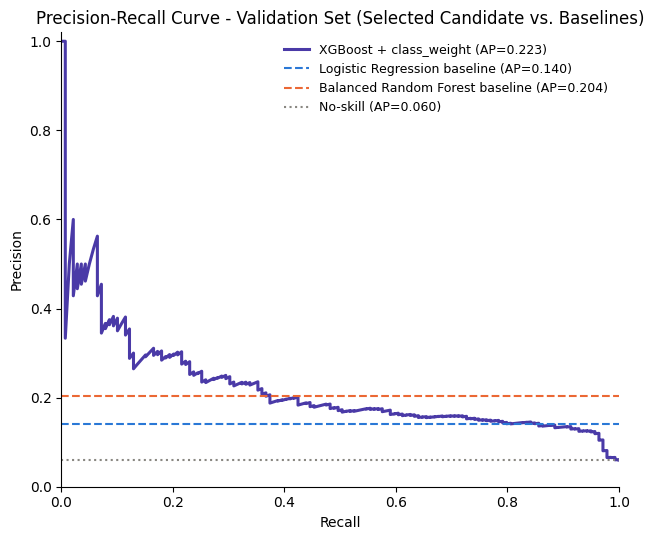

In [19]:
def save_figure(fig, filename: str, note: str = "") -> Path:
    """Save a figure to the modelling figures directory, record it, and print the path."""
    out_path = FIGURES_MODELLING_DIR / filename
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    saved_files.append(out_path)
    print(f"Saved figure -> {out_path}" + (f"  ({note})" if note else ""))
    return out_path


fig, ax = plt.subplots(figsize=(6.5, 5.5))

precision, recall, _ = precision_recall_curve(y_val, best_val_result["y_proba"])
ax.plot(recall, precision, color=PALETTE["violet"], linewidth=2.2,
        label=f"{candidate_label} (AP={val_pr_auc:.3f})")

baseline_line_colors = {"Logistic Regression": PALETTE["blue"], "Balanced Random Forest": PALETTE["orange"]}
for _, row in baseline_metrics.iterrows():
    ax.axhline(row["pr_auc"], color=baseline_line_colors.get(row["model"], PALETTE["green"]),
               linestyle="--", linewidth=1.5, label=f"{row['model']} baseline (AP={row['pr_auc']:.3f})")

ax.axhline(no_skill_pr_auc, color="#898781", linestyle=":", linewidth=1.5,
           label=f"No-skill (AP={no_skill_pr_auc:.3f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve - Validation Set (Selected Candidate vs. Baselines)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.legend(loc="upper right", frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

save_figure(fig, "pr_curve_candidate_vs_baselines.png", note=candidate_label)
plt.show()

## 12. Save the Selected Model

The fitted model (refit on the full training data in Section 10) and its
full configuration are saved to Drive. No calibration or thresholding happens
here — that's Notebooks 05-06.

In [20]:
best_model_path = MODELS_DIR / "best_model.joblib"
joblib.dump(best_val_result["model"], best_model_path)
saved_files.append(best_model_path)
print(f"Saved -> {best_model_path}")

reloaded_model = joblib.load(best_model_path)
_ = reloaded_model.predict_proba(X_val[:3])
print("Reloaded the saved model from disk and confirmed .predict_proba() works on it.")

Saved -> /content/drive/MyDrive/InsuranceFraudProject/models/best_model.joblib
Reloaded the saved model from disk and confirmed .predict_proba() works on it.


In [21]:
def to_jsonable(value):
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    return value


best_model_config = {
    "model_name": best_experiment.model_name,
    "balancing_strategy": best_experiment.balancing_strategy,
    "hyperparameters": {k: to_jsonable(v) for k, v in best_experiment.hyperparameters.items()},
    "seed": RANDOM_STATE,
    "early_stopping_rounds": best_experiment.early_stopping_rounds,
    "optuna": {
        "trial_number": best_trial.number,
        "n_trials": N_TRIALS,
        "sampler": "TPESampler",
        "pruner": "MedianPruner(n_startup_trials=10, n_warmup_steps=2)",
    },
    "cv_pr_auc_mean": to_jsonable(best_cv_summary["pr_auc_mean"]),
    "cv_pr_auc_std": to_jsonable(best_cv_summary["pr_auc_std"]),
    "val_metrics": {k: to_jsonable(v) for k, v in best_val_result["metrics"].items()},
    "beats_balanced_rf_baseline": bool(val_pr_auc > balanced_rf_val_pr_auc),
    "balanced_rf_baseline_val_pr_auc": to_jsonable(balanced_rf_val_pr_auc),
    "generated_at": datetime.now(timezone.utc).isoformat(),
}

best_config_path = MODELS_DIR / "best_model_config.json"
with open(best_config_path, "w", encoding="utf-8") as f:
    json.dump(best_model_config, f, indent=2)
saved_files.append(best_config_path)
print(f"Saved -> {best_config_path}")
display(Markdown(f"```json\n{json.dumps(best_model_config, indent=2)}\n```"))

Saved -> /content/drive/MyDrive/InsuranceFraudProject/models/best_model_config.json


```json
{
  "model_name": "XGBoost",
  "balancing_strategy": "class_weight",
  "hyperparameters": {
    "learning_rate": 0.01460240515659235,
    "max_depth": 9,
    "n_estimators": 477,
    "subsample": 0.8843211990638039,
    "colsample_bytree": 0.697871410139674,
    "reg_alpha": 0.3093738646769364,
    "reg_lambda": 7.539411306510498e-07,
    "min_child_weight": 4
  },
  "seed": 42,
  "early_stopping_rounds": 50,
  "optuna": {
    "trial_number": 58,
    "n_trials": 100,
    "sampler": "TPESampler",
    "pruner": "MedianPruner(n_startup_trials=10, n_warmup_steps=2)"
  },
  "cv_pr_auc_mean": 0.2810485518898197,
  "cv_pr_auc_std": 0.04857990734082353,
  "val_metrics": {
    "pr_auc": 0.22253391147774496,
    "recall": 0.7482014388489209,
    "precision": 0.15072463768115943,
    "macro_f1": 0.5436772666377144,
    "mcc": 0.24864140029668835,
    "roc_auc": 0.8171986789593164,
    "brier_score": 0.14297271733115105
  },
  "beats_balanced_rf_baseline": true,
  "balanced_rf_baseline_val_pr_auc": 0.2044393448572477,
  "generated_at": "2026-08-29T07:49:11.546966+00:00"
}
```

## 13. Sanity Checks

Each check targets a specific way this notebook could go wrong.

### Optuna searched all four candidate arms and logged every trial

In [22]:
trials_df = pd.DataFrame([
    {"number": t.number, "state": t.state.name, **{k: v for k, v in t.params.items()}}
    for t in study.trials
])

arms_seen = set(zip(trials_df["model_name"], trials_df["balancing_strategy"]))
expected_arms = {("XGBoost", "class_weight"), ("XGBoost", "SMOTENC"),
                  ("LightGBM", "class_weight"), ("LightGBM", "SMOTENC")}
missing_arms = expected_arms - arms_seen
assert not missing_arms, f"Optuna never sampled these arm(s): {missing_arms}"

assert len(study.trials) == N_TRIALS, (
    f"Expected {N_TRIALS} trials, study has {len(study.trials)}."
)
assert isinstance(study.sampler, optuna.samplers.TPESampler), "Sampler is not TPESampler."
assert isinstance(study.pruner, optuna.pruners.MedianPruner), "Pruner is not MedianPruner."

experiments_log = pd.read_csv(EXPERIMENTS_CSV_PATH, parse_dates=["timestamp"])
this_run_trial_rows = experiments_log[
    experiments_log["eval_split"].astype(str).str.startswith("cv_trial_")
    & (experiments_log["timestamp"] >= search_started_at)
]
# Scoped to rows logged during *this* run's search - experiments.csv accumulates across
# re-runs by design (Section 4's log_experiment never overwrites), so counting every
# cv_trial_* row ever written would wrongly fail as soon as this notebook is re-run.
n_trial_rows_logged = len(this_run_trial_rows)
assert n_trial_rows_logged == N_TRIALS, (
    f"Expected {N_TRIALS} trial rows logged to experiments.csv in this run, found {n_trial_rows_logged}."
)

print(f"PASSED: all 4 candidate arms were searched, {N_TRIALS} trials ran with "
      f"TPESampler + MedianPruner, and all {N_TRIALS} were logged to experiments.csv "
      f"({n_completed} completed, {n_pruned} pruned).")

PASSED: all 4 candidate arms were searched, 100 trials ran with TPESampler + MedianPruner, and all 100 were logged to experiments.csv (63 completed, 37 pruned).


### The overfitting gap and CV std were recorded, not just the point estimate

In [23]:
assert "pr_auc_std" in best_cv_summary, "CV std was not recorded for the best trial."
assert np.isfinite(best_cv_summary["pr_auc_std"]), "CV std is not a finite number."
assert np.isfinite(overfit_gap), "Overfit gap (CV PR-AUC minus validation PR-AUC) is not finite."
print(f"PASSED: CV std ({best_cv_summary['pr_auc_std']:.4f}) and the CV-vs-validation "
      f"gap ({overfit_gap:.4f}) were both recorded above, not discarded.")

PASSED: CV std (0.0486) and the CV-vs-validation gap (0.0585) were both recorded above, not discarded.


### The selected model's fitted state didn't change when scoring validation

In [24]:
def snapshot_fitted_state(model) -> np.ndarray:
    """Grab one representative fitted attribute, to detect an accidental refit later.
    Unwraps a Pipeline step and/or an EarlyStoppingGBDT wrapper to reach the actual
    fitted classifier."""
    target = model
    if hasattr(target, "steps"):
        target = target.steps[-1][1]
    if isinstance(target, EarlyStoppingGBDT):
        target = target.estimator_
    if hasattr(target, "coef_"):
        return target.coef_.copy()
    if hasattr(target, "feature_importances_"):
        return np.asarray(target.feature_importances_).copy()
    raise AttributeError(f"Don't know how to snapshot fitted state for {type(target).__name__}")


fitted_model = best_val_result["model"]
before = snapshot_fitted_state(fitted_model)
_ = fitted_model.predict(X_val)
_ = fitted_model.predict_proba(X_val)
after = snapshot_fitted_state(fitted_model)
assert np.array_equal(before, after), (
    "The selected model's fitted state changed after scoring validation - it must never be refit."
)
print("PASSED: the selected model's fitted state did not change when scoring validation.")

PASSED: the selected model's fitted state did not change when scoring validation.


### The test set was never touched

In [25]:
assert "test_df" not in dir() and "X_test" not in dir() and "y_test" not in dir(), (
    "Test set must not be loaded or referenced in this notebook - it is opened once, "
    "later, in Notebook 06."
)
print("PASSED: test.parquet / test_df / X_test / y_test are absent from this notebook's namespace.")

PASSED: test.parquet / test_df / X_test / y_test are absent from this notebook's namespace.


All sanity checks passed. If the arm-coverage or trial-count checks ever fail
on a re-run, treat it as a hard stop before trusting `best_model.joblib` -
they'd mean the search didn't actually cover the space this notebook claims
to have searched.

## Modelling & Selection Summary

In [26]:
beats_text = (
    f"beats the Balanced Random Forest baseline ({val_pr_auc:.3f} > {balanced_rf_val_pr_auc:.3f})"
    if val_pr_auc > balanced_rf_val_pr_auc else
    f"does NOT beat the Balanced Random Forest baseline ({val_pr_auc:.3f} <= {balanced_rf_val_pr_auc:.3f}) "
    "- reported honestly, not forced"
)

summary_md = f"""
**Search:** {N_TRIALS} Optuna trials ({n_completed} completed, {n_pruned} pruned) across all
four candidate arms (XGBoost/LightGBM x class_weight/SMOTENC), objective = mean 5-fold
CV PR-AUC on training data, TPE sampler + median pruner, seed {RANDOM_STATE}. Every trial
is logged in `experiments.csv`.

**Selected configuration:** `{candidate_label}` (trial #{best_trial.number}) -
CV PR-AUC {best_cv_summary['pr_auc_mean']:.3f} +/- {best_cv_summary['pr_auc_std']:.3f},
validation PR-AUC {val_pr_auc:.3f}. This candidate {beats_text}.

**Overfitting check:** CV-to-validation gap was {overfit_gap:.3f}
({'flagged above the watch threshold' if overfit_gap > OVERFIT_GAP_WARNING_THRESHOLD else 'within the watch threshold'}) -
see Section 10 for the full reasoning. CV PR-AUC is an estimate from 5 resampled
subsets of the same training data, not a guarantee; the validation number is the more
trustworthy one where they disagree.

**What this notebook does not claim:** this is a model selected on validation/CV, not
a real-world performance number - that comes only from Notebook 06's single, locked
test-set evaluation. No calibration, thresholding, or risk-tier logic has been applied
to `best_model.joblib` yet. Effect sizes here are expected to be modest, consistent with
Notebooks 01-03's findings on this dataset.

**All sanity checks passed:** all 4 candidate arms searched, {N_TRIALS} trials logged,
TPE sampler + median pruner active, CV std and the overfitting gap recorded (not
discarded), no fitted-state drift when scoring validation, and the test set was never
referenced.

**Saved to Drive:** `best_model.joblib`, `best_model_config.json`, the updated
`experiments.csv`, and the comparison PR-curve figure.

**Open items for Notebook 05 onward:**
1. `best_model.joblib`'s raw probabilities are not yet calibrated - reliability curves
   and Brier-score-driven recalibration (Platt/isotonic) happen in Notebook 05.
2. Operating threshold and Low/Med/High risk-tier boundaries are set in Notebook 05,
   on validation - never on test.
3. Notebook 06 opens the locked test set exactly once, after calibration and
   thresholds are frozen, for the final, real evaluation number.
"""
display(Markdown(summary_md))


**Search:** 100 Optuna trials (63 completed, 37 pruned) across all
four candidate arms (XGBoost/LightGBM x class_weight/SMOTENC), objective = mean 5-fold
CV PR-AUC on training data, TPE sampler + median pruner, seed 42. Every trial
is logged in `experiments.csv`.

**Selected configuration:** `XGBoost + class_weight` (trial #58) -
CV PR-AUC 0.281 +/- 0.049,
validation PR-AUC 0.223. This candidate beats the Balanced Random Forest baseline (0.223 > 0.204).

**Overfitting check:** CV-to-validation gap was 0.059
(flagged above the watch threshold) -
see Section 10 for the full reasoning. CV PR-AUC is an estimate from 5 resampled
subsets of the same training data, not a guarantee; the validation number is the more
trustworthy one where they disagree.

**What this notebook does not claim:** this is a model selected on validation/CV, not
a real-world performance number - that comes only from Notebook 06's single, locked
test-set evaluation. No calibration, thresholding, or risk-tier logic has been applied
to `best_model.joblib` yet. Effect sizes here are expected to be modest, consistent with
Notebooks 01-03's findings on this dataset.

**All sanity checks passed:** all 4 candidate arms searched, 100 trials logged,
TPE sampler + median pruner active, CV std and the overfitting gap recorded (not
discarded), no fitted-state drift when scoring validation, and the test set was never
referenced.

**Saved to Drive:** `best_model.joblib`, `best_model_config.json`, the updated
`experiments.csv`, and the comparison PR-curve figure.

**Open items for Notebook 05 onward:**
1. `best_model.joblib`'s raw probabilities are not yet calibrated - reliability curves
   and Brier-score-driven recalibration (Platt/isotonic) happen in Notebook 05.
2. Operating threshold and Low/Med/High risk-tier boundaries are set in Notebook 05,
   on validation - never on test.
3. Notebook 06 opens the locked test set exactly once, after calibration and
   thresholds are frozen, for the final, real evaluation number.


### Files saved by this notebook

In [27]:
print("Modelling outputs written this run:")
for p in saved_files:
    print(f"  - {p}")

Modelling outputs written this run:
  - /content/drive/MyDrive/InsuranceFraudProject/results/figures/modelling/pr_curve_candidate_vs_baselines.png
  - /content/drive/MyDrive/InsuranceFraudProject/models/best_model.joblib
  - /content/drive/MyDrive/InsuranceFraudProject/models/best_model_config.json
